In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

arima  = pd.read_csv('../results/arima_results.csv')
xgb    = pd.read_csv('../results/xgboost_results.csv')
rf     = pd.read_csv('../results/rf_results.csv')
lstm   = pd.read_csv('../results/lstm_results.csv')

models = {'ARIMA': arima, 'XGBoost': xgb, 'Random Forest': rf, 'LSTM': lstm}


In [ ]:
# Celda 2: Tabla comparativa (tabla principal de la memoria)
# Baseline correcto: AUC = 0.5 (azar), no ARIMA.
import sys, os
sys.path.insert(0, os.path.join('..', 'models'))
from statistical_tests import test_vs_random

rows = []
for name, df in models.items():
    r = test_vs_random(df.auc.tolist(), name)
    rows.append({
        'Modelo':          name,
        'Accuracy (mean)': f"{df.accuracy.mean():.3f}",
        'Accuracy (std)':  f"+/-{df.accuracy.std():.3f}",
        'F1-Score':        f"{df.f1.mean():.3f}",
        'AUC-ROC':         f"{r['auc_mean']:.4f}",
        'IC 95%':          f"[{r['ci_95'][0]:.3f}, {r['ci_95'][1]:.3f}]",
        'p vs azar':       f"{r['p_value']:.4f}",
        'Sig. (α=0.05)':   'SI' if r['significant'] else 'NO',
    })

tabla = pd.DataFrame(rows)
print(tabla.to_string(index=False))
print()
print("NOTA: Baseline = 0.5 (azar puro). Comparar contra ARIMA (AUC=0.49)")
print("      es un baseline más débil que el azar y produce ilusión de superioridad.")


In [ ]:
# Celda 3: Tests estadísticos rigurosos — H0: AUC = 0.5
import sys, os
sys.path.insert(0, os.path.join('..', 'models'))
from statistical_tests import print_full_report, compare_models, power_analysis

models_aucs = {name: df.auc.tolist() for name, df in models.items()}
print_full_report(models_aucs)

# Comparaciones pareadas entre modelos
print("\n" + "=" * 70)
print("COMPARACIONES PAREADAS (Wilcoxon / t-test pareado)")
print("=" * 70)
pairs = [('LSTM', 'ARIMA'), ('XGBoost', 'ARIMA'), ('Random Forest', 'ARIMA')]
for a, b in pairs:
    if a in models_aucs and b in models_aucs:
        r = compare_models(models_aucs[a], models_aucs[b], a, b)
        print(f"\n{r['comparison']} ({r['test_used']})")
        print(f"  Diferencia AUC medio: {r['diff_mean']:+.4f}")
        print(f"  p-value: {r['p_value']:.4f}  ->  {r['conclusion']}")

# Análisis de poder estadístico
n = len(list(models_aucs.values())[0])
pow_ = power_analysis(effect_size=0.05, n_splits=n)
print(f"\nPODER ESTADÍSTICO (delta=0.05, n={n} splits): {pow_:.1%}")
print("Mejoras reales de AUC+0.05 tienen ~80% de probabilidad de NO detectarse.")
print("Esto limita el poder confirmatorio del estudio, NO invalida los resultados.")

# Celda 4: Gráfica de boxplot de métricas por modelo
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['accuracy', 'f1', 'auc']
titles  = ['Accuracy', 'F1-Score', 'AUC-ROC']

for ax, metric, title in zip(axes, metrics, titles):
    data  = [df[metric].values for df in models.values()]
    names = list(models.keys())
    ax.boxplot(data, labels=names)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(metric)
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Azar (0.5)')
    ax.legend(fontsize=8)

plt.suptitle('Comparativa de modelos (walk-forward validation, 4 splits x 90 dias)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_comparativa_modelos.png', dpi=150)
plt.show()


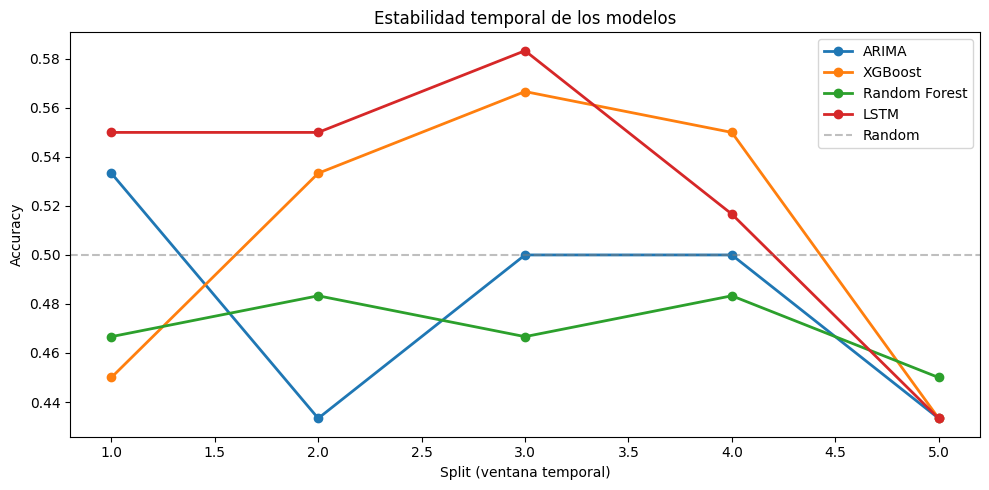

In [4]:
# Celda 5: Evolucion temporal de accuracy por split
fig, ax = plt.subplots(figsize=(10, 5))
for name, df in models.items():
    ax.plot(df.split, df.accuracy, marker='o', label=name, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
ax.set_xlabel('Split (ventana temporal)')
ax.set_ylabel('Accuracy')
ax.set_title('Estabilidad temporal de los modelos')
ax.legend()
plt.tight_layout()
plt.savefig('eda_estabilidad_temporal.png', dpi=150)
plt.show()
